In [138]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree

In [139]:
#1: Data Understanding
df=pd.read_csv("Loan Approval Prediction .csv")
print(df.head())

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


In [140]:
df.shape

(32581, 12)

In [141]:
df.dtypes

person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

In [142]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [143]:
df.duplicated().sum()

np.int64(165)

In [144]:
# Drop duplicate rows
df = df.drop_duplicates()



In [145]:
df.shape

(32416, 12)

In [146]:
#2: Data Preprocessing 
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
f = pd.read_csv("Loan Approval Prediction .csv")

In [147]:

# Numerical columns → Mean
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

# Categorical columns → Mode
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())
print("\nUpdated Dataset:")
print(df.head())

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

Updated Dataset:
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATIO

In [148]:
# Identify categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
print("Categorical Columns:", cat_cols)

Categorical Columns: Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')


In [149]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df['scaled_amt'] = scaler.fit_transform(df[['loan_amnt']])

print(df[['loan_amnt', 'scaled_amt']].head())


   loan_amnt  scaled_amt
0      35000    1.000000
1       1000    0.014493
2       5500    0.144928
3      35000    1.000000
4      35000    1.000000


In [150]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['loan_status'])   
y = df['loan_status']                 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (25932, 12)
Testing set size: (6484, 12)


In [151]:
df.dtypes

person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
scaled_amt                    float64
dtype: object

In [152]:
df.columns


Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length',
       'scaled_amt'],
      dtype='object')

In [153]:
#3: Model Building 
import pandas as pd

X = df.drop(columns=['loan_status'])
y = df['loan_status']

X = pd.get_dummies(X, drop_first=True,dtype=int)

print(X.head())  

   person_age  person_income  person_emp_length  loan_amnt  loan_int_rate  \
0          22          59000              123.0      35000          16.02   
1          21           9600                5.0       1000          11.14   
2          25           9600                1.0       5500          12.87   
3          23          65500                4.0      35000          15.23   
4          24          54400                8.0      35000          14.27   

   loan_percent_income  cb_person_cred_hist_length  scaled_amt  \
0                 0.59                           3    1.000000   
1                 0.10                           2    0.014493   
2                 0.57                           3    0.144928   
3                 0.53                           2    1.000000   
4                 0.55                           4    1.000000   

   person_home_ownership_OTHER  person_home_ownership_OWN  ...  \
0                            0                          0  ...   
1       

In [154]:
from sklearn.tree import DecisionTreeClassifier

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [155]:
from sklearn.metrics import accuracy_score, classification_report
# 1. Decision Tree with Gini
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_train, y_train)
y_pred_gini = dt_gini.predict(X_test)

print("Gini Accuracy:", accuracy_score(y_test, y_pred_gini))
print("Gini Report:\n", classification_report(y_test, y_pred_gini))

Gini Accuracy: 0.8918877236273905
Gini Report:
               precision    recall  f1-score   support

           0       0.94      0.93      0.93      5066
           1       0.74      0.77      0.76      1418

    accuracy                           0.89      6484
   macro avg       0.84      0.85      0.84      6484
weighted avg       0.89      0.89      0.89      6484



In [156]:
# 2. Decision Tree with Entropy
dt_en = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_en.fit(X_train, y_train)
y_pred_en = dt_en.predict(X_test)

print("Entropy Accuracy:", accuracy_score(y_test, y_pred_en))
print("Entropy Report:\n", classification_report(y_test, y_pred_en))

Entropy Accuracy: 0.8901912399753239
Entropy Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93      5066
           1       0.74      0.76      0.75      1418

    accuracy                           0.89      6484
   macro avg       0.84      0.84      0.84      6484
weighted avg       0.89      0.89      0.89      6484



In [157]:
#Module 4: Model Evaluation
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Gini Criterion")
print("Accuracy:", accuracy_score(y_test, y_pred_gini))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gini))
print("Classification Report:\n", classification_report(y_test, y_pred_gini))

print("\nEntropy Criterion")
print("Accuracy:", accuracy_score(y_test, y_pred_en))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_en))
print("Classification Report:\n", classification_report(y_test, y_pred_en))

Gini Criterion
Accuracy: 0.8918877236273905
Confusion Matrix:
 [[4687  379]
 [ 322 1096]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.93      0.93      5066
           1       0.74      0.77      0.76      1418

    accuracy                           0.89      6484
   macro avg       0.84      0.85      0.84      6484
weighted avg       0.89      0.89      0.89      6484


Entropy Criterion
Accuracy: 0.8901912399753239
Confusion Matrix:
 [[4691  375]
 [ 337 1081]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93      5066
           1       0.74      0.76      0.75      1418

    accuracy                           0.89      6484
   macro avg       0.84      0.84      0.84      6484
weighted avg       0.89      0.89      0.89      6484



In [161]:
#5. 5: Tree Visualization
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
dt_model = DecisionTreeClassifier(
    criterion='gini', 
    max_depth=3, 
    max_leaf_nodes=5, 
    random_state=42)

dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,5
,min_impurity_decrease,0.0
,class_weight,None


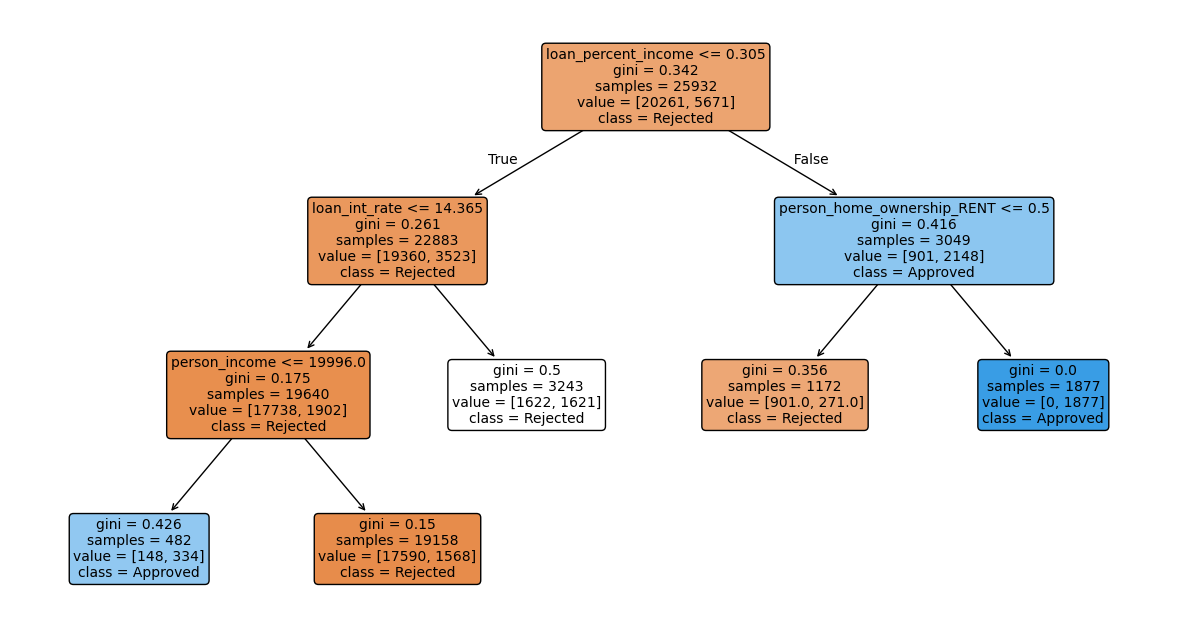

In [162]:
plt.figure(figsize=(15,8))
plot_tree(dt_model,
          feature_names=X.columns,
          class_names=['Rejected','Approved'], 
          filled=True,
          rounded=True,
          fontsize=10)
plt.show()

In [164]:
# Feature importance (decision nodes)
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_gini.feature_importances_})

importance = importance.sort_values( by='Importance', ascending=False)

print(importance)

                        Feature  Importance
5           loan_percent_income    0.228580
4                 loan_int_rate    0.158919
1                 person_income    0.138880
10   person_home_ownership_RENT    0.134265
2             person_emp_length    0.053195
0                    person_age    0.044097
18                 loan_grade_D    0.026027
13          loan_intent_MEDICAL    0.025810
6    cb_person_cred_hist_length    0.025745
3                     loan_amnt    0.025403
12  loan_intent_HOMEIMPROVEMENT    0.025222
7                    scaled_amt    0.022912
17                 loan_grade_C    0.019641
14         loan_intent_PERSONAL    0.018092
11        loan_intent_EDUCATION    0.012380
15          loan_intent_VENTURE    0.010300
9     person_home_ownership_OWN    0.010067
22  cb_person_default_on_file_Y    0.006821
19                 loan_grade_E    0.006273
16                 loan_grade_B    0.002170
21                 loan_grade_G    0.002056
8   person_home_ownership_OTHER 

In [168]:
#6: Hyperparameter Tuning
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

In [171]:
print("Before Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Before Accuracy: 0.8918877236273905
Confusion Matrix:
 [[4687  379]
 [ 322 1096]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.93      0.93      5066
           1       0.74      0.77      0.76      1418

    accuracy                           0.89      6484
   macro avg       0.84      0.85      0.84      6484
weighted avg       0.89      0.89      0.89      6484



In [170]:
dt_t = DecisionTreeClassifier(criterion='gini',max_depth=5,min_samples_split=10,min_samples_leaf=5,random_state=42)
dt_t.fit(X_train, y_train)
y_pred_t = dt_t.predict(X_test)

In [172]:
print("After Accuracy:", accuracy_score(y_test, y_pred_t))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_t))
print("Classification Report:\n", classification_report(y_test, y_pred_t))

After Accuracy: 0.9054595928439235
Confusion Matrix:
 [[5031   35]
 [ 578  840]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.99      0.94      5066
           1       0.96      0.59      0.73      1418

    accuracy                           0.91      6484
   macro avg       0.93      0.79      0.84      6484
weighted avg       0.91      0.91      0.90      6484



In [174]:
import pandas as pd

importances = dt_t.feature_importances_
feat_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_importances.head(10))


                        Feature  Importance
5           loan_percent_income    0.363878
10   person_home_ownership_RENT    0.208482
4                 loan_int_rate    0.194395
1                 person_income    0.099314
18                 loan_grade_D    0.040972
13          loan_intent_MEDICAL    0.031657
17                 loan_grade_C    0.028972
2             person_emp_length    0.028424
11        loan_intent_EDUCATION    0.001990
8   person_home_ownership_OTHER    0.001916


In [177]:
train=dt.score(X_train,y_train)
test=dt.score(X_test,y_test)
print("train accuracy:",train)
print("test accuracy:",test)

train accuracy: 1.0
test accuracy: 0.8918877236273905
